In [1]:
%matplotlib inline

In [ ]:
from Tuner import tune_parameters
from ParamTuners import ParamTuner, tuningPlotter, parse_mixed_csv, getPositionFromData, getVelocityFromData
from Runner import run_simulation
from Config import MODEL_T, CONTROL_STRATEGY, CONTROL_MODE


def simulate(result):
    run_simulation(
        initial_state=[0.0, 0.0, 0.0, 0.0],
        time_span=(0, 10),
        control_mode=CONTROL_MODE.VELOCITY,
        controller_type=CONTROL_STRATEGY.PD,
        desired_gamma=0.0,
        desired_velocity=0.5,
        desired_position=0.0,
        model_type=MODEL_T.ROLLING_RESISTANCE,
        record_Torque=False,
        export_CSV_flag=False,
        plot_results=False,
        export2list=result
    )

print("Loading real data from CSV...")

mode_segments = parse_mixed_csv("c:\\Users\\labuser\\Desktop\\unicycle_project_umich\\LOGS\\ValidLogs\\log_2026-04-01_14-20-46.533.csv")
data = None
for item in mode_segments:
    if item['mode'] == 'velocity':
        data = item['data'] # the last veloicity 

if data is None:
    print("Mode Segments:", mode_segments)
    raise ValueError("No velocity data found in the CSV file.")

realdata = getVelocityFromData(data)
print(realdata)

def penaltyFunc(resultStorage):
    error = 0.0

    if realdata is None or len(realdata) == 0:
        raise ValueError("Real data is empty, cannot compute penalty.")
    if resultStorage is None or len(resultStorage) == 0:
        raise ValueError("Simulation result is empty, cannot compute penalty.")
    
    numeric_results = []

    tcolumn = resultStorage[0]  #  the first column is time
    vcolumn = resultStorage[2]  #  third column is velocity


    for t, v in zip(tcolumn, vcolumn):
        numeric_results.append((t, v))

    times = [t/10 for t in range(0,100)] # 0 to 10 seconds with 0.01s intervals

    for t in times:
        closest_time_simu = min(numeric_results, key=lambda x: abs(x[0] - t))
        closest_time_real = min(realdata, key=lambda x: abs(x[0] - t))

        #print(closest_time_simu, closest_time_real)

        # print(f"Time: {t:.2f} s, Simulated Velocity: {closest_time_simu[1]:.4f}, Real Velocity: {closest_time_real[1]:.4f}")

        error += (closest_time_simu[1] - closest_time_real[1]) ** 2

    return error / len(times)    



best_params = tune_parameters(paramDict =  {'B': 0.009355712797712799, 'B_0': 0.0011494577536160012, 'mu_rolling': 0.0025357458535808356, 'I': 0.6385543701447575},
                                simulation=simulate,
                                realdata=realdata,
                                ax_real_name="Real Velocity Data",
                                ax_try_name="Simulated Velocity Data",
                                penaltyFunc=penaltyFunc,
                                columnIndex = 2, # [x_c, x_c_dot, gamma, gamma_dot] we want to compare the velocity which is at index 2， (time is at 0)
                                max_iterations=50,
                                )

It's better to use all the data we tested multiple times for velocity.

In [ ]:
from Tuner import tune_parameters
from ParamTuners import ParamTuner, tuningPlotter, parse_mixed_csv, getPositionFromData, getVelocityFromData
from Runner import run_simulation
from Config import MODEL_T, CONTROL_STRATEGY, CONTROL_MODE
from Parameters import params


def simulate(result):
    run_simulation(
        initial_state=[0.0, 0.0, 0.0, 0.0],
        time_span=(0, 16),
        control_mode=CONTROL_MODE.VELOCITY,
        controller_type=CONTROL_STRATEGY.PD,
        desired_gamma=0.0,
        desired_velocity=0.5,
        desired_position=0.0,
        model_type=MODEL_T.ROLLING_RESISTANCE,
        record_Torque=False,
        export_CSV_flag=False,
        plot_results=False,
        export2list=result
    )

print("Loading real data from CSV...")
filenames = [
    '/Users/a123/Documents/Unicycle/unicycle_project_umich/LOGS/ValidLogs/V0.5x3.csv',
    '/Users/a123/Documents/Unicycle/unicycle_project_umich/LOGS/ValidLogs/V0.5x3(2).csv',
]

dataList = []

for file in filenames:
    mode_segments = parse_mixed_csv(file)

    for item in mode_segments:
        if item['mode'] == 'velocity':
        
            dataList.append(item['data'])        

if dataList is None:
    print("Mode Segments:", mode_segments)
    raise ValueError("No position data found in the CSV file.")

realdataList = [(i, getVelocityFromData(val)) for i, val in enumerate(dataList)]

# remove faulty data
faultylist = [7,4,2,5,6]
realdataList = [data for i, data in enumerate(realdataList) if i not in faultylist]


def penaltyFunc(resultStorage):
    error = 0.0

    if realdataList is None or len(realdataList) == 0:
        raise ValueError("Real data is empty, cannot compute penalty.")
    if resultStorage is None or len(resultStorage) == 0:
        raise ValueError("Simulation result is empty, cannot compute penalty.")
    
    numeric_results = []

    tcolumn = resultStorage[0]  #  the first column is time
    vcolumn = resultStorage[2]  #  third column is velocity


    for t, v in zip(tcolumn, vcolumn):
        numeric_results.append((t, v))

    times = [t/10 for t in range(0,150)] 

    for i, realdata in realdataList:

        for t in times:
            closest_time_simu = min(numeric_results, key=lambda x: abs(x[0] - t))
            closest_time_real = min(realdata, key=lambda x: abs(x[0] - t))

            #print(closest_time_simu, closest_time_real)

            # print(f"Time: {t:.2f} s, Simulated Velocity: {closest_time_simu[1]:.4f}, Real Velocity: {closest_time_real[1]:.4f}")

            error += (closest_time_simu[1] - closest_time_real[1]) ** 2

    return error / (len(times) * len(realdataList))

params.I = 0.104

# velcity data {'B': 0.29534719835953205, 'B_0': 0.012007420032393943, 'mu_rolling': 0.010143346358048193, 'm_w': 6.555652034148903, 'm': 0.7443479658510976}

best_params = tune_parameters(paramDict = {'B': 0.29534719835953205, 'B_0': 0.012007420032393943, 'mu_rolling': 0.010143346358048193, 'm_w': 6.555652034148903, 'm': 0.7443479658510976},
                                simulation=simulate,
                                realdata=realdataList,
                                ax_real_name="Real Velocity Data",
                                ax_try_name="Simulated Velocity Data",
                                penaltyFunc=penaltyFunc,
                                columnIndex = 2, # [x_c, x_c_dot, gamma, gamma_dot] we want to compare the velocity which is at index 2， (time is at 0)
                                max_iterations=50,
                                )

- Also the same param in position mode

In [ ]:
from Tuner import tune_parameters
from ParamTuners import ParamTuner, tuningPlotter, parse_mixed_csv, getPositionFromData, getVelocityFromData
from Runner import run_simulation
from Config import MODEL_T, CONTROL_STRATEGY, CONTROL_MODE
from Parameters import params


def simulate(result):
    run_simulation(
        initial_state=[0.0, 0.0, 0.0, 0.0],
        time_span=(0, 17),
        control_mode=CONTROL_MODE.POSITION,
        controller_type=CONTROL_STRATEGY.PD,
        desired_gamma=0.0,
        desired_velocity=0.0,
        desired_position=1.0,
        model_type=MODEL_T.ROLLING_RESISTANCE,
        record_Torque=False,
        export_CSV_flag=False,
        plot_results=False,
        export2list=result
    )

print("Loading real data from CSV...")
filenames = [
    '/Users/a123/Documents/Unicycle/unicycle_project_umich/LOGS/ValidLogs/P1.0x3.csv',
    '/Users/a123/Documents/Unicycle/unicycle_project_umich/LOGS/ValidLogs/P1.0x3(2).csv',
]

dataList = []

for file in filenames:
    mode_segments = parse_mixed_csv(file)

    for item in mode_segments:
        if item['mode'] == 'position':
        
            dataList.append(item['data'])        

if dataList is None:
    print("Mode Segments:", mode_segments)
    raise ValueError("No position data found in the CSV file.")

realdataList = [(i, getPositionFromData(val)) for i, val in enumerate(dataList)]

# remove faulty data
# faultylist = [7,4,2,5,6]
# realdataList = [data for i, data in enumerate(realdataList) if i not in faultylist]


def penaltyFunc(resultStorage):
    error = 0.0

    if realdataList is None or len(realdataList) == 0:
        raise ValueError("Real data is empty, cannot compute penalty.")
    if resultStorage is None or len(resultStorage) == 0:
        raise ValueError("Simulation result is empty, cannot compute penalty.")
    
    numeric_results = []

    tcolumn = resultStorage[0]  #  the first column is time
    vcolumn = resultStorage[1]  #  third column is velocity.. for position data, it's at index 1, second column


    for t, v in zip(tcolumn, vcolumn):
        numeric_results.append((t, v))

    times = [t/10 for t in range(0,100)] 

    for i, realdata in realdataList:

        for t in times:
            closest_time_simu = min(numeric_results, key=lambda x: abs(x[0] - t))
            closest_time_real = min(realdata, key=lambda x: abs(x[0] - t))

            #print(closest_time_simu, closest_time_real)

            # print(f"Time: {t:.2f} s, Simulated Velocity: {closest_time_simu[1]:.4f}, Real Velocity: {closest_time_real[1]:.4f}")

            error += (closest_time_simu[1] - closest_time_real[1]) ** 2

    return error / (len(times) * len(realdataList))

params.I = 0.104

# velcity data {'B': 0.29534719835953205, 'B_0': 0.012007420032393943, 'mu_rolling': 0.010143346358048193, 'm_w': 6.555652034148903, 'm': 0.7443479658510976}

best_params = tune_parameters(paramDict =  {'B': 0.3412352909215786, 'B_0': 0.011337090552689628, 'mu_rolling': 0.009937861087525632, 'm_w': 6.509289047678268, 'm': 0.7907109523217312},
                                simulation=simulate,
                                realdata=realdataList,
                                ax_real_name="Real Position Data",
                                ax_try_name="Simulated Position Data",
                                penaltyFunc=penaltyFunc,
                                columnIndex = 1, # [x_c, x_c_dot, gamma, gamma_dot] we want to compare the velocity which is at index 2， (time is at 0)
                                max_iterations=0,
                                )

## Position mode gamma angle comparison

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ParamTuners import parse_mixed_csv
from Runner import run_simulation
from Config import MODEL_T, CONTROL_STRATEGY, CONTROL_MODE
from Parameters import params

REAL_RUN_COLOR = '#9ca3af'
POSITION_SIM_COLOR = '#f59e0b'
VELOCITY_SIM_COLOR = '#3860e0'
TARGET_COLOR = '#dc2626'
PLOT_OUTPUT_DIR = Path('/Users/a123/Documents/Unicycle/Matlab_Simu4Unicycle/Derivation/Segway/Plots/gamma_comparison')


def activate_inline_matplotlib():
    try:
        from IPython import get_ipython
        ipython = get_ipython()
        if ipython is not None:
            ipython.run_line_magic('matplotlib', 'inline')
        plt.switch_backend('module://matplotlib_inline.backend_inline')
    except Exception as exc:
        print(f'Could not switch matplotlib to inline backend: {exc}')


activate_inline_matplotlib()


def safe_plot_filename(title):
    return ''.join(char if char.isalnum() else '_' for char in title).strip('_').lower()


def save_and_show_figure(fig, title):
    output_dir = PLOT_OUTPUT_DIR
    try:
        output_dir.mkdir(parents=True, exist_ok=True)
    except PermissionError:
        output_dir = Path('/tmp/unicycle_mujoco_plots') / PLOT_OUTPUT_DIR.name
        output_dir.mkdir(parents=True, exist_ok=True)
        print(f'Plot directory was not writable; using fallback: {output_dir}')

    output_path = output_dir / f'{safe_plot_filename(title)}.png'
    fig.savefig(output_path, dpi=160, bbox_inches='tight')
    print(f'Plot saved to: {output_path}')
    plt.show()
    return output_path




def sim_color_for_mode(mode_name):
    return VELOCITY_SIM_COLOR if str(mode_name).lower() == 'velocity' else POSITION_SIM_COLOR


def style_axis(axis):
    axis.grid(False)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
    axis.tick_params(direction='out')


def style_legend(axis):
    axis.legend(frameon=False)


def mean_segment_trace(segments, value_index=1, time_limit=15, sample_dt=0.05):
    sample_time = np.arange(0.0, time_limit + sample_dt, sample_dt)
    traces = []

    for segment in segments:
        real_time = np.asarray(segment[0], dtype=float)
        real_value = np.asarray(segment[value_index], dtype=float)
        valid = (sample_time >= real_time.min()) & (sample_time <= real_time.max())
        trace = np.full(sample_time.shape, np.nan, dtype=float)
        trace[valid] = np.interp(sample_time[valid], real_time, real_value)
        traces.append(trace)

    stacked = np.vstack(traces)
    valid_columns = np.any(~np.isnan(stacked), axis=0)
    return sample_time[valid_columns], np.nanmean(stacked[:, valid_columns], axis=0)


def get_gamma_deg_from_segment(segment_data, time_limit=15):
    trimmed_rows = [row for row in segment_data if row[0] <= time_limit]
    times = [row[0] for row in trimmed_rows]
    gamma_deg_values = [np.degrees(row[2]) for row in trimmed_rows]
    return times, gamma_deg_values


def collect_mode_gamma_segments(file_paths, mode_name, target_value, runs_per_file=3, time_limit=15):
    real_gamma_segments = []

    for file_path in file_paths:
        mode_segments = parse_mixed_csv(file_path)
        selected_segments = [
            item['data']
            for item in mode_segments
            if item['mode'] == mode_name and item['target_value'] == target_value
        ]

        for segment_data in selected_segments[:runs_per_file]:
            real_gamma_segments.append(get_gamma_deg_from_segment(segment_data, time_limit=time_limit))

    return real_gamma_segments


def simulate_gamma(control_mode, desired_velocity, desired_position, param_dict, time_limit=15):
    params.I = 0.104
    params.updateParams(param_dict)

    sim_result = []
    run_simulation(
        initial_state=[0.0, 0.0, 0.0, 0.0],
        time_span=(0, 18),
        control_mode=control_mode,
        controller_type=CONTROL_STRATEGY.PD,
        desired_gamma=0.0,
        desired_velocity=desired_velocity,
        desired_position=desired_position,
        model_type=MODEL_T.ROLLING_RESISTANCE,
        record_Torque=False,
        export_CSV_flag=False,
        plot_results=False,
        export2list=sim_result,
    )

    return np.array(sim_result[0]), np.degrees(np.array(sim_result[3]))


def plot_gamma_comparison(title, file_paths, mode_name, target_value, control_mode, desired_velocity, desired_position, param_dict, runs_per_file=3, time_limit=15):
    real_gamma_segments = collect_mode_gamma_segments(
        file_paths=file_paths,
        mode_name=mode_name,
        target_value=target_value,
        runs_per_file=runs_per_file,
        time_limit=time_limit,
    )
    print(f'Loaded {len(real_gamma_segments)} real gamma runs for {title}.')

    fig, axis = plt.subplots(figsize=(10, 5))
    for idx, (exp_t, exp_gamma_deg) in enumerate(real_gamma_segments):
        axis.plot(
            exp_t,
            exp_gamma_deg,
            color=REAL_RUN_COLOR,
            linewidth=1.6,
            alpha=0.65,
            label='Real Gamma' if idx == 0 else None,
        )

    sim_t, sim_gamma_deg = simulate_gamma(
        control_mode=control_mode,
        desired_velocity=desired_velocity,
        desired_position=desired_position,
        param_dict=param_dict,
        time_limit=time_limit,
    )
    axis.plot(sim_t, sim_gamma_deg, color=sim_color_for_mode(mode_name), linewidth=3.0, label='Simulated Gamma')

    axis.set_xlabel('Time (s)')
    axis.set_ylabel('Gamma (deg)')
    axis.set_xlim(0, time_limit)
    style_axis(axis)
    style_legend(axis)
    plt.tight_layout()
    save_and_show_figure(fig, title)


shared_gamma_params = {
    'B': 0.3412352909215786,
    'B_0': 0.011337090552689628,
    'mu_rolling': 0.009937861087525632,
    'm_w': 6.509289047678268,
    'm': 0.7907109523217312,
}

position_gamma_filenames = [
    '/Users/a123/Documents/Unicycle/unicycle_project_umich/LOGS/ValidLogs/P1.0x3.csv',
    '/Users/a123/Documents/Unicycle/unicycle_project_umich/LOGS/ValidLogs/P1.0x3(2).csv',
]

plot_gamma_comparison(
    title='Position Mode Gamma Angle Comparison',
    file_paths=position_gamma_filenames,
    mode_name='position',
    target_value=1.0,
    control_mode=CONTROL_MODE.POSITION,
    desired_velocity=0.0,
    desired_position=1.0,
    param_dict=shared_gamma_params,
    runs_per_file=3,
    time_limit=14,
)


## Velocity mode gamma angle comparison

In [ ]:
velocity_gamma_filenames = [
    '/Users/a123/Documents/Unicycle/unicycle_project_umich/LOGS/ValidLogs/V0.5x3.csv',
    '/Users/a123/Documents/Unicycle/unicycle_project_umich/LOGS/ValidLogs/V0.5x3(2).csv',
]

plot_gamma_comparison(
    title='Velocity Mode Gamma Angle Comparison',
    file_paths=velocity_gamma_filenames,
    mode_name='velocity',
    target_value=0.5,
    control_mode=CONTROL_MODE.VELOCITY,
    desired_velocity=0.5,
    desired_position=0.0,
    param_dict=shared_gamma_params,
    runs_per_file=3,
    time_limit=14,
)


## Position mode: simu.py CSV vs real data

Compare the CSV generated by `simu.py` with the position-mode experiment logs. This section only reads existing CSV/log data and does not tune or update any parameters.


In [ ]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import sys
SEGWAY_PARAM_TUNERS_DIR = Path('/Users/a123/Documents/Unicycle/Matlab_Simu4Unicycle/Derivation/Segway/ParamTuners')
if str(SEGWAY_PARAM_TUNERS_DIR) not in sys.path:
    sys.path.insert(0, str(SEGWAY_PARAM_TUNERS_DIR))
from getRealData import parse_mixed_csv

MUJOCO_SIM_CSV_DIR = Path('/Users/a123/Desktop/ME_490/Unicycle_Mujoco_Simulation/csv/mydata')

REAL_RUN_COLOR = '#9ca3af'
POSITION_SIM_COLOR = '#f59e0b'
VELOCITY_SIM_COLOR = '#3860e0'
TARGET_COLOR = '#dc2626'
PLOT_OUTPUT_DIR = Path('/Users/a123/Documents/Unicycle/Matlab_Simu4Unicycle/Derivation/Segway/Plots/csv_comparison')


def activate_inline_matplotlib():
    try:
        from IPython import get_ipython
        ipython = get_ipython()
        if ipython is not None:
            ipython.run_line_magic('matplotlib', 'inline')
        plt.switch_backend('module://matplotlib_inline.backend_inline')
    except Exception as exc:
        print(f'Could not switch matplotlib to inline backend: {exc}')


activate_inline_matplotlib()


def safe_plot_filename(title):
    return ''.join(char if char.isalnum() else '_' for char in title).strip('_').lower()


def save_and_show_figure(fig, title):
    output_dir = PLOT_OUTPUT_DIR
    try:
        output_dir.mkdir(parents=True, exist_ok=True)
    except PermissionError:
        output_dir = Path('/tmp/unicycle_mujoco_plots') / PLOT_OUTPUT_DIR.name
        output_dir.mkdir(parents=True, exist_ok=True)
        print(f'Plot directory was not writable; using fallback: {output_dir}')

    output_path = output_dir / f'{safe_plot_filename(title)}.png'
    fig.savefig(output_path, dpi=160, bbox_inches='tight')
    print(f'Plot saved to: {output_path}')
    plt.show()
    return output_path




def sim_color_for_mode(mode_name):
    return VELOCITY_SIM_COLOR if str(mode_name).lower() == 'velocity' else POSITION_SIM_COLOR


def style_axis(axis):
    axis.grid(False)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
    axis.tick_params(direction='out')


def style_legend(axis):
    axis.legend(frameon=False)


def mean_segment_trace(segments, value_index=1, time_limit=15, sample_dt=0.05):
    sample_time = np.arange(0.0, time_limit + sample_dt, sample_dt)
    traces = []

    for segment in segments:
        real_time = np.asarray(segment[0], dtype=float)
        real_value = np.asarray(segment[value_index], dtype=float)
        valid = (sample_time >= real_time.min()) & (sample_time <= real_time.max())
        trace = np.full(sample_time.shape, np.nan, dtype=float)
        trace[valid] = np.interp(sample_time[valid], real_time, real_value)
        traces.append(trace)

    stacked = np.vstack(traces)
    valid_columns = np.any(~np.isnan(stacked), axis=0)
    return sample_time[valid_columns], np.nanmean(stacked[:, valid_columns], axis=0)


def load_simu_csv(csv_path):
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(f'MuJoCo CSV not found: {csv_path}')

    rows = []
    with csv_path.open(newline='') as csv_file:
        reader = csv.DictReader(csv_file)
        for row in reader:
            rows.append({key: float(value) for key, value in row.items()})

    if not rows:
        raise ValueError(f'MuJoCo CSV is empty: {csv_path}')

    columns = rows[0].keys()
    return {column: np.array([row[column] for row in rows], dtype=float) for column in columns}


def collect_real_mode_segments(file_paths, mode_name, target_value, value_column, runs_per_file=3, time_limit=15, exclude_run_indices=None):
    exclude_run_indices = set(exclude_run_indices or [])
    real_segments = []

    for file_path in file_paths:
        mode_segments = parse_mixed_csv(str(file_path))
        selected_segments = [
            item['data']
            for item in mode_segments
            if item['mode'] == mode_name and np.isclose(item['target_value'], target_value)
        ]

        for segment_data in selected_segments[:runs_per_file]:
            trimmed_rows = [row for row in segment_data if row[0] <= time_limit]
            if not trimmed_rows:
                continue

            time = np.array([row[0] for row in trimmed_rows], dtype=float)
            value = np.array([row[value_column] for row in trimmed_rows], dtype=float)
            gamma_deg = np.degrees(np.array([row[2] for row in trimmed_rows], dtype=float))
            real_segments.append((time, value, gamma_deg))

    real_segments = [segment for idx, segment in enumerate(real_segments) if idx not in exclude_run_indices]

    if not real_segments:
        raise ValueError(f'No real {mode_name} data found for target {target_value}.')

    return real_segments


def rmse_by_real_run(sim_time, sim_value, real_segments, time_limit=15, sample_dt=0.1):
    sample_time = np.arange(0.0, time_limit + sample_dt, sample_dt)
    sim_interp = np.interp(sample_time, sim_time, sim_value)
    errors = []

    for real_time, real_value, _ in real_segments:
        valid = (sample_time >= real_time.min()) & (sample_time <= real_time.max())
        real_interp = np.interp(sample_time[valid], real_time, real_value)
        error = np.sqrt(np.mean((sim_interp[valid] - real_interp) ** 2))
        errors.append(error)

    return errors


def plot_simu_csv_vs_real(
    title,
    sim_csv_path,
    real_file_paths,
    mode_name,
    target_value,
    sim_value_column,
    real_value_column,
    value_label,
    time_limit=15,
    runs_per_file=3,
    exclude_run_indices=None,
):
    sim_data = load_simu_csv(sim_csv_path)
    sim_time = sim_data['time'] - sim_data['time'][0]
    sim_value = sim_data[sim_value_column]
    sim_gamma_deg = np.degrees(sim_data['gamma'])

    real_segments = collect_real_mode_segments(
        file_paths=real_file_paths,
        mode_name=mode_name,
        target_value=target_value,
        value_column=real_value_column,
        runs_per_file=runs_per_file,
        time_limit=time_limit,
        exclude_run_indices=exclude_run_indices,
    )

    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
    sim_color = sim_color_for_mode(mode_name)

    for idx, (real_time, real_value, real_gamma_deg) in enumerate(real_segments):
        axes[0].plot(real_time, real_value, color=REAL_RUN_COLOR, alpha=0.55, linewidth=1.4, label=f'Real {value_label}' if idx == 0 else None)
        axes[1].plot(real_time, real_gamma_deg, color=REAL_RUN_COLOR, alpha=0.55, linewidth=1.4, label='Real gamma' if idx == 0 else None)

    axes[0].plot(sim_time, sim_value, color=sim_color, linewidth=2.8, label='simu.py CSV')
    axes[1].plot(sim_time, sim_gamma_deg, color=sim_color, linewidth=2.8, label='simu.py CSV gamma')
    axes[0].axhline(target_value, color=TARGET_COLOR, linestyle='--', linewidth=1.3, label=f'Target {target_value:g}')

    axes[0].set_ylabel(value_label)
    axes[1].set_ylabel('Gamma (deg)')
    axes[1].set_xlabel('Time (s)')

    for axis in axes:
        axis.set_xlim(0, time_limit)
        style_axis(axis)
        style_legend(axis)

    main_errors = rmse_by_real_run(sim_time, sim_value, real_segments, time_limit=time_limit)
    gamma_errors = rmse_by_real_run(sim_time, sim_gamma_deg, [(t, g, g) for t, _, g in real_segments], time_limit=time_limit)
    print(f'Loaded {len(real_segments)} real {mode_name} runs.')
    formatted_main_errors = ', '.join(f'{err:.4f}' for err in main_errors)
    print(f'{value_label} RMSE by run: [{formatted_main_errors}]')
    print(f'{value_label} mean RMSE: {np.mean(main_errors):.4f}')
    print(f'Gamma mean RMSE (deg): {np.mean(gamma_errors):.4f}')

    plt.tight_layout()
    save_and_show_figure(fig, title)


position_real_filenames = [
    '/Users/a123/Documents/Unicycle/unicycle_project_umich/LOGS/ValidLogs/P1.0x3.csv',
    '/Users/a123/Documents/Unicycle/unicycle_project_umich/LOGS/ValidLogs/P1.0x3(2).csv',
]

plot_simu_csv_vs_real(
    title='Position Mode: simu.py CSV vs Real Data',
    sim_csv_path=MUJOCO_SIM_CSV_DIR / 'position.csv',
    real_file_paths=position_real_filenames,
    mode_name='position',
    target_value=1.0,
    sim_value_column='x_c',
    real_value_column=3,
    value_label='Position (m)',
    time_limit=14,
    runs_per_file=3,
)


## Velocity mode: simu.py CSV vs real data

Compare the velocity-mode CSV generated by `simu.py` with the velocity-mode experiment logs. This section reuses the plotting helpers above and does not run tuning.


In [ ]:
velocity_real_filenames = [
    '/Users/a123/Documents/Unicycle/unicycle_project_umich/LOGS/ValidLogs/V0.5x3.csv',
    '/Users/a123/Documents/Unicycle/unicycle_project_umich/LOGS/ValidLogs/V0.5x3(2).csv',
]

plot_simu_csv_vs_real(
    title='Velocity Mode: simu.py CSV vs Real Data',
    sim_csv_path=MUJOCO_SIM_CSV_DIR / 'velocity.csv',
    real_file_paths=velocity_real_filenames,
    mode_name='velocity',
    target_value=0.5,
    sim_value_column='x_c_dot',
    real_value_column=4,
    value_label='Velocity (m/s)',
    time_limit=15,
    runs_per_file=3,
    exclude_run_indices=[2, 4, 5],
)


## Position mode: tune MuJoCo out.xml to real data

Tune the MuJoCo XML parameters used by `simu.py` so the generated position-mode CSV better matches the experiment data. The search can adjust the two masses, `friction[0]`, `friction[2]`, and the hinge damping; it saves a timestamped backup before writing the best XML.


In [ ]:
import contextlib
import csv
import importlib.util
import io
import os
import subprocess
import shutil
import sys
import xml.etree.ElementTree as ET
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

SEGWAY_PARAM_TUNERS_DIR = Path('/Users/a123/Documents/Unicycle/Matlab_Simu4Unicycle/Derivation/Segway/ParamTuners')
if str(SEGWAY_PARAM_TUNERS_DIR) not in sys.path:
    sys.path.insert(0, str(SEGWAY_PARAM_TUNERS_DIR))
from getRealData import parse_mixed_csv

MUJOCO_PROJECT_DIR = Path('/Users/a123/Desktop/ME_490/Unicycle_Mujoco_Simulation')
SIMU_PY_PATH = MUJOCO_PROJECT_DIR / 'simu.py'
XML_PATH = MUJOCO_PROJECT_DIR / 'Model' / 'out.xml'
SIM_CSV_DIR = MUJOCO_PROJECT_DIR / 'csv' / 'mydata'

# Use the current notebook kernel if it has mujoco installed. Otherwise set this
# to the Python executable that you normally use to run simu.py. You can also
# set the MUJOCO_PYTHON environment variable before starting Jupyter.
MUJOCO_PYTHON = os.environ.get('MUJOCO_PYTHON', sys.executable)

TUNE_PARAMETER_NAMES = [
    'wheel_mass',
    'block_mass',
    'friction_1',
    'friction_3',
    'hinge_damping',
]

PARAMETER_BOUNDS = {
    'wheel_mass': (5.0, 10.0),
    'block_mass': (0.20, 2.00),
    'friction_1': (0.20, 2.00),
    'friction_3': (0.00005, 0.02000),
    'hinge_damping': (0.01, 2.00),
}
MASS_SUM_BOUNDS = (6.5, 8.0)

PARAMETER_MULTIPLIERS = [0.60, 0.80, 1.00, 1.25, 1.60]
NUM_PASSES = 1
APPLY_BEST_TO_OUT_XML = True
REAL_RUN_COLOR = '#9ca3af'
POSITION_SIM_COLOR = '#f59e0b'
VELOCITY_SIM_COLOR = '#3860e0'
BEST_SIM_COLOR = VELOCITY_SIM_COLOR
TARGET_COLOR = '#dc2626'
PLOT_OUTPUT_DIR = Path('/Users/a123/Documents/Unicycle/Matlab_Simu4Unicycle/Derivation/Segway/Plots/xml_tuning')


def activate_inline_matplotlib():
    try:
        from IPython import get_ipython
        ipython = get_ipython()
        if ipython is not None:
            ipython.run_line_magic('matplotlib', 'inline')
        plt.switch_backend('module://matplotlib_inline.backend_inline')
    except Exception as exc:
        print(f'Could not switch matplotlib to inline backend: {exc}')


activate_inline_matplotlib()


def safe_plot_filename(title):
    return ''.join(char if char.isalnum() else '_' for char in title).strip('_').lower()


def save_and_show_figure(fig, title):
    output_dir = PLOT_OUTPUT_DIR
    try:
        output_dir.mkdir(parents=True, exist_ok=True)
    except PermissionError:
        output_dir = Path('/tmp/unicycle_mujoco_plots') / PLOT_OUTPUT_DIR.name
        output_dir.mkdir(parents=True, exist_ok=True)
        print(f'Plot directory was not writable; using fallback: {output_dir}')

    output_path = output_dir / f'{safe_plot_filename(title)}.png'
    fig.savefig(output_path, dpi=160, bbox_inches='tight')
    print(f'Plot saved to: {output_path}')
    plt.show()
    return output_path




def sim_color_for_mode(mode_name):
    return VELOCITY_SIM_COLOR if str(mode_name).lower() == 'velocity' else POSITION_SIM_COLOR


def style_axis(axis):
    axis.grid(False)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
    axis.tick_params(direction='out')


def style_legend(axis):
    axis.legend(frameon=False)


def mean_segment_trace(segments, value_index=1, time_limit=15, sample_dt=0.05):
    sample_time = np.arange(0.0, time_limit + sample_dt, sample_dt)
    traces = []

    for segment in segments:
        real_time = np.asarray(segment[0], dtype=float)
        real_value = np.asarray(segment[value_index], dtype=float)
        valid = (sample_time >= real_time.min()) & (sample_time <= real_time.max())
        trace = np.full(sample_time.shape, np.nan, dtype=float)
        trace[valid] = np.interp(sample_time[valid], real_time, real_value)
        traces.append(trace)

    stacked = np.vstack(traces)
    valid_columns = np.any(~np.isnan(stacked), axis=0)
    return sample_time[valid_columns], np.nanmean(stacked[:, valid_columns], axis=0)


def fmt_xml_float(value):
    return f'{float(value):.8g}'


def parse_float_list(value):
    return [float(item) for item in value.split()]


def constrain_mass_pair(params_to_constrain):
    constrained = dict(params_to_constrain)
    if 'wheel_mass' not in constrained or 'block_mass' not in constrained:
        return constrained

    wheel_lower, wheel_upper = PARAMETER_BOUNDS['wheel_mass']
    block_lower, block_upper = PARAMETER_BOUNDS['block_mass']
    sum_lower, sum_upper = MASS_SUM_BOUNDS

    wheel_mass = float(np.clip(constrained['wheel_mass'], wheel_lower, wheel_upper))
    block_mass = float(np.clip(constrained['block_mass'], block_lower, block_upper))
    total_mass = wheel_mass + block_mass

    if total_mass < sum_lower:
        needed = sum_lower - total_mass
        block_room = block_upper - block_mass
        block_add = min(needed, block_room)
        block_mass += block_add
        needed -= block_add
        wheel_mass += min(needed, wheel_upper - wheel_mass)
    elif total_mass > sum_upper:
        excess = total_mass - sum_upper
        block_room = block_mass - block_lower
        block_subtract = min(excess, block_room)
        block_mass -= block_subtract
        excess -= block_subtract
        wheel_mass -= min(excess, wheel_mass - wheel_lower)

    constrained['wheel_mass'] = float(np.clip(wheel_mass, wheel_lower, wheel_upper))
    constrained['block_mass'] = float(np.clip(block_mass, block_lower, block_upper))
    return constrained


def constrain_parameters(params_to_constrain):
    constrained = dict(params_to_constrain)
    for name, value in list(constrained.items()):
        if name in PARAMETER_BOUNDS:
            lower, upper = PARAMETER_BOUNDS[name]
            constrained[name] = float(np.clip(value, lower, upper))
    return constrain_mass_pair(constrained)


def load_xml_tree():
    return ET.parse(XML_PATH)


def find_required(root, path):
    node = root.find(path)
    if node is None:
        raise ValueError(f'Could not find XML path: {path}')
    return node


def read_xml_parameters():
    tree = load_xml_tree()
    root = tree.getroot()
    wheel_inertial = find_required(root, "./worldbody/body[@name='wheel']/inertial")
    block_geom = find_required(root, "./worldbody/body[@name='wheel']/body[@name='box_link']/geom[@name='block_geom']")
    default_geom = find_required(root, './default/geom')
    hinge_joint = find_required(root, "./worldbody/body[@name='wheel']/body[@name='box_link']/joint[@name='box_hinge']")
    friction = parse_float_list(default_geom.get('friction'))

    return {
        'wheel_mass': float(wheel_inertial.get('mass')),
        'block_mass': float(block_geom.get('mass')),
        'friction_1': friction[0],
        'friction_3': friction[2],
        'hinge_damping': float(hinge_joint.get('damping')),
    }


def write_xml_parameters(params_to_write):
    tree = load_xml_tree()
    root = tree.getroot()
    wheel_inertial = find_required(root, "./worldbody/body[@name='wheel']/inertial")
    block_geom = find_required(root, "./worldbody/body[@name='wheel']/body[@name='box_link']/geom[@name='block_geom']")
    default_geom = find_required(root, './default/geom')
    hinge_joint = find_required(root, "./worldbody/body[@name='wheel']/body[@name='box_link']/joint[@name='box_hinge']")

    current = read_xml_parameters()
    merged = constrain_parameters({**current, **params_to_write})

    friction = parse_float_list(default_geom.get('friction'))
    friction[0] = merged['friction_1']
    friction[2] = merged['friction_3']

    wheel_inertial.set('mass', fmt_xml_float(merged['wheel_mass']))
    block_geom.set('mass', fmt_xml_float(merged['block_mass']))
    default_geom.set('friction', ' '.join(fmt_xml_float(item) for item in friction))
    hinge_joint.set('damping', fmt_xml_float(merged['hinge_damping']))

    ET.indent(tree, space='  ')
    tree.write(XML_PATH, encoding='unicode', xml_declaration=False)


def current_kernel_has_mujoco():
    return importlib.util.find_spec('mujoco') is not None


def check_external_mujoco_python():
    command = [MUJOCO_PYTHON, '-c', 'import mujoco; print(mujoco.__version__)']
    completed = subprocess.run(command, capture_output=True, text=True)
    if completed.returncode != 0:
        raise RuntimeError(
            'The notebook kernel does not have mujoco, and MUJOCO_PYTHON cannot import mujoco.\n'
            f'MUJOCO_PYTHON is currently: {MUJOCO_PYTHON}\n'
            'Set MUJOCO_PYTHON to the Python executable that can run simu.py, for example:\n'
            "    MUJOCO_PYTHON = '/path/to/python'\n"
            'or install mujoco in this notebook kernel.\n\n'
            f'stdout:\n{completed.stdout}\n'
            f'stderr:\n{completed.stderr}'
        )


def check_simu_runner_available():
    if current_kernel_has_mujoco():
        return
    check_external_mujoco_python()


def load_simu_module():
    module_name = 'mujoco_simu_for_xml_tuning'
    if module_name in sys.modules:
        del sys.modules[module_name]
    spec = importlib.util.spec_from_file_location(module_name, SIMU_PY_PATH)
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module


def run_simu_in_current_kernel(mode_name, sim_duration):
    simu = load_simu_module()
    old_cwd = os.getcwd()
    try:
        os.chdir(MUJOCO_PROJECT_DIR)
        simu.RUN_MODE = simu.RunMode.P
        simu.CTRL_MODE = simu.ControlMode.P if mode_name == 'position' else simu.ControlMode.V
        simu.SIM_DURATION = float(sim_duration)
        simu.GenerateCsv = True
        with contextlib.redirect_stdout(io.StringIO()):
            simu.main()
    finally:
        os.chdir(old_cwd)


def run_simu_in_external_python(mode_name, sim_duration):
    control_mode_name = 'P' if mode_name == 'position' else 'V'
    wrapper_code = f"""
import contextlib
import importlib.util
import io
import os
import sys
from pathlib import Path

project_dir = Path({str(MUJOCO_PROJECT_DIR)!r})
simu_py_path = Path({str(SIMU_PY_PATH)!r})
spec = importlib.util.spec_from_file_location('mujoco_simu_for_xml_tuning_external', simu_py_path)
simu = importlib.util.module_from_spec(spec)
sys.modules['mujoco_simu_for_xml_tuning_external'] = simu
spec.loader.exec_module(simu)
os.chdir(project_dir)
simu.RUN_MODE = simu.RunMode.P
simu.CTRL_MODE = simu.ControlMode.{control_mode_name}
simu.SIM_DURATION = {float(sim_duration)!r}
simu.GenerateCsv = True
with contextlib.redirect_stdout(io.StringIO()):
    simu.main()
"""
    completed = subprocess.run(
        [MUJOCO_PYTHON, '-c', wrapper_code],
        cwd=MUJOCO_PROJECT_DIR,
        capture_output=True,
        text=True,
    )
    if completed.returncode != 0:
        raise RuntimeError(
            f'simu.py failed in external Python: {MUJOCO_PYTHON}\n'
            f'stdout:\n{completed.stdout}\n'
            f'stderr:\n{completed.stderr}'
        )


def run_simu_to_csv(mode_name, sim_duration):
    if current_kernel_has_mujoco():
        run_simu_in_current_kernel(mode_name, sim_duration)
    else:
        run_simu_in_external_python(mode_name, sim_duration)

    csv_path = SIM_CSV_DIR / f'{mode_name}.csv'
    if not csv_path.exists():
        raise FileNotFoundError(f'simu.py did not generate expected CSV: {csv_path}')
    return csv_path


def load_simu_csv(csv_path):
    rows = []
    with Path(csv_path).open(newline='') as csv_file:
        reader = csv.DictReader(csv_file)
        for row in reader:
            rows.append({key: float(value) for key, value in row.items()})
    if not rows:
        raise ValueError(f'Empty simulation CSV: {csv_path}')
    return {column: np.array([row[column] for row in rows], dtype=float) for column in rows[0].keys()}


def collect_real_segments(file_paths, mode_name, target_value, value_column, runs_per_file=3, time_limit=15, exclude_run_indices=None):
    exclude_run_indices = set(exclude_run_indices or [])
    real_segments = []

    for file_path in file_paths:
        mode_segments = parse_mixed_csv(str(file_path))
        selected_segments = [
            item['data']
            for item in mode_segments
            if item['mode'] == mode_name and np.isclose(item['target_value'], target_value)
        ]

        for segment_data in selected_segments[:runs_per_file]:
            trimmed_rows = [row for row in segment_data if row[0] <= time_limit]
            if not trimmed_rows:
                continue
            real_time = np.array([row[0] for row in trimmed_rows], dtype=float)
            real_value = np.array([row[value_column] for row in trimmed_rows], dtype=float)
            real_gamma_deg = np.degrees(np.array([row[2] for row in trimmed_rows], dtype=float))
            real_segments.append((real_time, real_value, real_gamma_deg))

    real_segments = [segment for idx, segment in enumerate(real_segments) if idx not in exclude_run_indices]
    if not real_segments:
        raise ValueError(f'No real {mode_name} data found for target {target_value}.')
    return real_segments


def rmse_against_real_runs(sim_time, sim_value, real_segments, real_index=1, time_limit=15, sample_dt=0.1):
    sample_time = np.arange(0.0, time_limit + sample_dt, sample_dt)
    errors = []

    for real_segment in real_segments:
        real_time = real_segment[0]
        real_value = real_segment[real_index]
        valid = (
            (sample_time >= real_time.min())
            & (sample_time <= real_time.max())
            & (sample_time >= sim_time.min())
            & (sample_time <= sim_time.max())
        )
        if valid.sum() < 2:
            continue
        sim_interp = np.interp(sample_time[valid], sim_time, sim_value)
        real_interp = np.interp(sample_time[valid], real_time, real_value)
        errors.append(float(np.sqrt(np.mean((sim_interp - real_interp) ** 2))))

    if not errors:
        return float('inf'), []
    return float(np.mean(errors)), errors


def score_current_simu_csv(mode_config):
    csv_path = SIM_CSV_DIR / f"{mode_config['mode_name']}.csv"
    sim_data = load_simu_csv(csv_path)
    sim_time = sim_data['time'] - sim_data['time'][0]
    sim_main_value = sim_data[mode_config['sim_value_column']]
    sim_gamma_deg = np.degrees(sim_data['gamma'])

    main_mean, main_errors = rmse_against_real_runs(
        sim_time,
        sim_main_value,
        mode_config['real_segments'],
        real_index=1,
        time_limit=mode_config['time_limit'],
    )
    gamma_mean, gamma_errors = rmse_against_real_runs(
        sim_time,
        sim_gamma_deg,
        mode_config['real_segments'],
        real_index=2,
        time_limit=mode_config['time_limit'],
    )
    score = main_mean + mode_config['gamma_weight'] * gamma_mean
    return score, main_mean, gamma_mean, main_errors, gamma_errors


def evaluate_xml_candidate(candidate_params, mode_config):
    try:
        write_xml_parameters(candidate_params)
        run_simu_to_csv(mode_config['mode_name'], mode_config['sim_duration'])
        return score_current_simu_csv(mode_config)
    except Exception as exc:
        print(f'Candidate failed: {exc}')
        return float('inf'), float('inf'), float('inf'), [], []


def clamp_parameter(name, value):
    lower, upper = PARAMETER_BOUNDS[name]
    return float(np.clip(value, lower, upper))


def make_scaled_candidate(best_params, parameter_name, multiplier):
    candidate = dict(best_params)
    candidate[parameter_name] = clamp_parameter(parameter_name, candidate[parameter_name] * multiplier)
    return constrain_parameters(candidate)


def format_params(params_to_format):
    return ', '.join(f'{name}={params_to_format[name]:.6g}' for name in TUNE_PARAMETER_NAMES)


def create_xml_backup(label):
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    backup_path = XML_PATH.with_name(f'out.xml.{label}.tuner_backup_{timestamp}')
    shutil.copy2(XML_PATH, backup_path)
    return backup_path


def coordinate_tune_mujoco_xml(mode_config):
    check_simu_runner_available()
    backup_path = create_xml_backup(mode_config['mode_name'])
    starting_params = constrain_parameters(read_xml_parameters())
    best_params = dict(starting_params)
    history = []

    print(f'Backup saved to: {backup_path}')
    print(f'Starting XML parameters: {format_params(best_params)}')

    best_score, best_main_rmse, best_gamma_rmse, _, _ = evaluate_xml_candidate(best_params, mode_config)
    history.append({'pass': 0, 'parameter': 'baseline', 'multiplier': 1.0, 'score': best_score, **best_params})
    print(f'Baseline score={best_score:.5f}, {mode_config["value_label"]} RMSE={best_main_rmse:.5f}, gamma RMSE={best_gamma_rmse:.5f}')

    for pass_index in range(1, NUM_PASSES + 1):
        improved_this_pass = False
        print(f'\nPass {pass_index}/{NUM_PASSES}')

        for parameter_name in mode_config['tune_parameter_names']:
            for multiplier in PARAMETER_MULTIPLIERS:
                if np.isclose(multiplier, 1.0):
                    continue

                candidate = make_scaled_candidate(best_params, parameter_name, multiplier)
                score, main_rmse, gamma_rmse, _, _ = evaluate_xml_candidate(candidate, mode_config)
                history.append({
                    'pass': pass_index,
                    'parameter': parameter_name,
                    'multiplier': multiplier,
                    'score': score,
                    **candidate,
                })
                print(
                    f'  {parameter_name} x {multiplier:.2f}: '
                    f'score={score:.5f}, {mode_config["value_label"]} RMSE={main_rmse:.5f}, gamma RMSE={gamma_rmse:.5f}'
                )

                if score < best_score:
                    best_score = score
                    best_main_rmse = main_rmse
                    best_gamma_rmse = gamma_rmse
                    best_params = candidate
                    improved_this_pass = True
                    print(f'    New best: {format_params(best_params)}')

        if not improved_this_pass:
            print('  No improvement in this pass; stopping early.')
            break

    if APPLY_BEST_TO_OUT_XML:
        write_xml_parameters(best_params)
        print('\nBest parameters were written to out.xml.')
    else:
        write_xml_parameters(starting_params)
        print('\nout.xml was restored to the starting parameters. Set APPLY_BEST_TO_OUT_XML=True to write the best result.')

    print(f'Best score={best_score:.5f}, {mode_config["value_label"]} RMSE={best_main_rmse:.5f}, gamma RMSE={best_gamma_rmse:.5f}')
    print(f'Best XML parameters: {format_params(best_params)}')
    return best_params, history


def plot_tuned_xml_result(mode_config, best_params, title):
    print('Re-running simu.py with the best XML parameters for the final plot...')
    write_xml_parameters(best_params)
    run_simu_to_csv(mode_config['mode_name'], mode_config['sim_duration'])
    sim_data = load_simu_csv(SIM_CSV_DIR / f"{mode_config['mode_name']}.csv")
    sim_time = sim_data['time'] - sim_data['time'][0]
    sim_main_value = sim_data[mode_config['sim_value_column']]
    sim_gamma_deg = np.degrees(sim_data['gamma'])

    sim_color = sim_color_for_mode(mode_config['mode_name'])

    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
    for idx, (real_time, real_value, real_gamma_deg) in enumerate(mode_config['real_segments']):
        axes[0].plot(real_time, real_value, color=REAL_RUN_COLOR, alpha=0.55, linewidth=1.4, label='Real data' if idx == 0 else None)
        axes[1].plot(real_time, real_gamma_deg, color=REAL_RUN_COLOR, alpha=0.55, linewidth=1.4, label='Real gamma' if idx == 0 else None)

    axes[0].plot(sim_time, sim_main_value, color=sim_color, linewidth=2.8, label='Tuned simu.py CSV')
    axes[1].plot(sim_time, sim_gamma_deg, color=sim_color, linewidth=2.8, label='Tuned simu.py CSV gamma')
    axes[0].axhline(mode_config['target_value'], color=TARGET_COLOR, linestyle='--', linewidth=1.3, label=f'Target {mode_config["target_value"]:g}')

    axes[0].set_ylabel(mode_config['value_label'])
    axes[1].set_ylabel('Gamma (deg)')
    axes[1].set_xlabel('Time (s)')

    for axis in axes:
        axis.set_xlim(0, mode_config['time_limit'])
        style_axis(axis)
        style_legend(axis)

    plt.tight_layout()
    save_and_show_figure(fig, title)


def plot_tuning_history(history, title):
    if not history:
        print('No tuning history to plot.')
        return

    scores = np.array([item['score'] for item in history], dtype=float)
    labels = [
        'baseline' if item['parameter'] == 'baseline' else f"{item['parameter']} x{item['multiplier']:.2f}"
        for item in history
    ]
    best_index = int(np.nanargmin(scores))

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(range(len(scores)), scores, color=BEST_SIM_COLOR, linewidth=1.8, marker='o', markersize=4)
    ax.scatter([best_index], [scores[best_index]], color=TARGET_COLOR, s=70, zorder=3, label='Best score')
    ax.set_xlabel('Candidate run')
    ax.set_ylabel('Score')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=55, ha='right', fontsize=8)
    style_axis(ax)
    style_legend(ax)
    plt.tight_layout()
    save_and_show_figure(fig, title)


position_xml_tuning_files = [
    '/Users/a123/Documents/Unicycle/unicycle_project_umich/LOGS/ValidLogs/P1.0x3.csv',
    '/Users/a123/Documents/Unicycle/unicycle_project_umich/LOGS/ValidLogs/P1.0x3(2).csv',
]

position_xml_tuning_config = {
    'mode_name': 'position',
    'target_value': 1.0,
    'sim_value_column': 'x_c',
    'real_value_column': 3,
    'value_label': 'Position (m)',
    'time_limit': 14,
    'sim_duration': 16,
    'runs_per_file': 3,
    'exclude_run_indices': [],
    'gamma_weight': 0.01,
    'tune_parameter_names': TUNE_PARAMETER_NAMES,
}
position_xml_tuning_config['real_segments'] = collect_real_segments(
    file_paths=position_xml_tuning_files,
    mode_name=position_xml_tuning_config['mode_name'],
    target_value=position_xml_tuning_config['target_value'],
    value_column=position_xml_tuning_config['real_value_column'],
    runs_per_file=position_xml_tuning_config['runs_per_file'],
    time_limit=position_xml_tuning_config['time_limit'],
    exclude_run_indices=position_xml_tuning_config['exclude_run_indices'],
)

position_best_xml_params, position_xml_tuning_history = coordinate_tune_mujoco_xml(position_xml_tuning_config)
plot_tuned_xml_result(position_xml_tuning_config, position_best_xml_params, 'Position Mode: tuned out.xml vs Real Data')
plot_tuning_history(position_xml_tuning_history, 'Position Mode: XML tuning score history')


## Velocity mode: tune MuJoCo out.xml to real data

Run the same MuJoCo XML search for velocity mode. This section reuses the XML tuning helpers from the position section, then writes the best velocity-mode result to `out.xml` with its own timestamped backup.


In [ ]:
velocity_xml_tuning_files = [
    '/Users/a123/Documents/Unicycle/unicycle_project_umich/LOGS/ValidLogs/V0.5x3.csv',
    '/Users/a123/Documents/Unicycle/unicycle_project_umich/LOGS/ValidLogs/V0.5x3(2).csv',
]

velocity_xml_tuning_config = {
    'mode_name': 'velocity',
    'target_value': 0.5,
    'sim_value_column': 'x_c_dot',
    'real_value_column': 4,
    'value_label': 'Velocity (m/s)',
    'time_limit': 14,
    'sim_duration': 16,
    'runs_per_file': 3,
    'exclude_run_indices': [2, 4, 5],
    'gamma_weight': 0.01,
    'tune_parameter_names': TUNE_PARAMETER_NAMES,
}
velocity_xml_tuning_config['real_segments'] = collect_real_segments(
    file_paths=velocity_xml_tuning_files,
    mode_name=velocity_xml_tuning_config['mode_name'],
    target_value=velocity_xml_tuning_config['target_value'],
    value_column=velocity_xml_tuning_config['real_value_column'],
    runs_per_file=velocity_xml_tuning_config['runs_per_file'],
    time_limit=velocity_xml_tuning_config['time_limit'],
    exclude_run_indices=velocity_xml_tuning_config['exclude_run_indices'],
)

velocity_best_xml_params, velocity_xml_tuning_history = coordinate_tune_mujoco_xml(velocity_xml_tuning_config)
plot_tuned_xml_result(velocity_xml_tuning_config, velocity_best_xml_params, 'Velocity Mode: tuned out.xml vs Real Data')
plot_tuning_history(velocity_xml_tuning_history, 'Velocity Mode: XML tuning score history')


## Python model vs MuJoCo vs real data

Plot the Python dynamics simulation, the MuJoCo CSV output, and the experimental data on the same axes for position mode and velocity mode.


Plot saved to: /Users/a123/Documents/Unicycle/Matlab_Simu4Unicycle/Derivation/Segway/Plots/python_mujoco_real_comparison/position_mode_python_mujoco_real_comparison.png


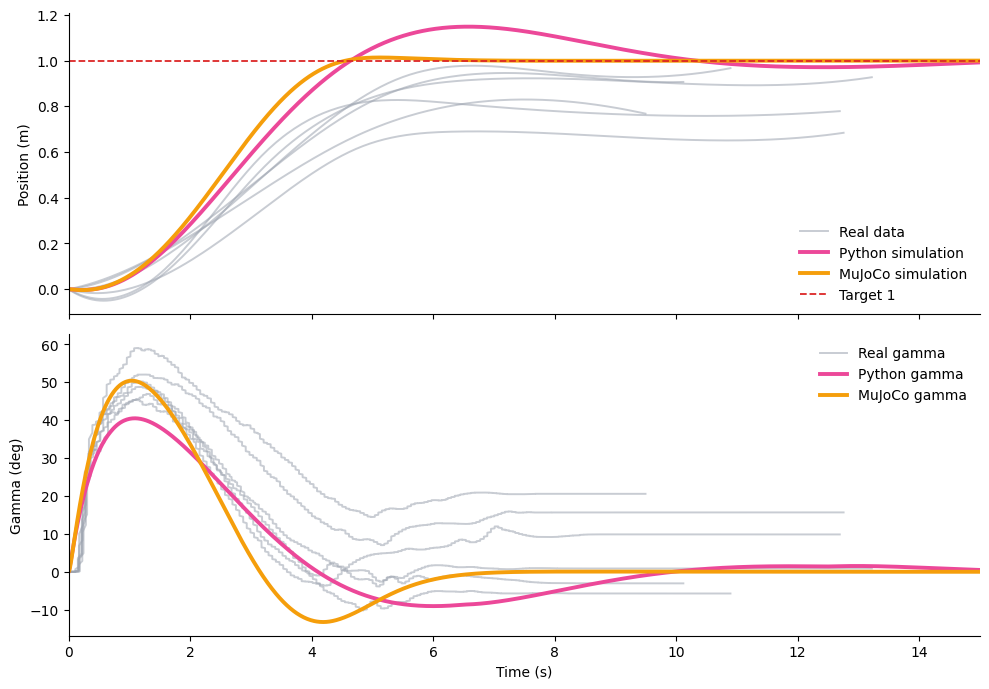

Plot saved to: /Users/a123/Documents/Unicycle/Matlab_Simu4Unicycle/Derivation/Segway/Plots/python_mujoco_real_comparison/velocity_mode_python_mujoco_real_comparison.png


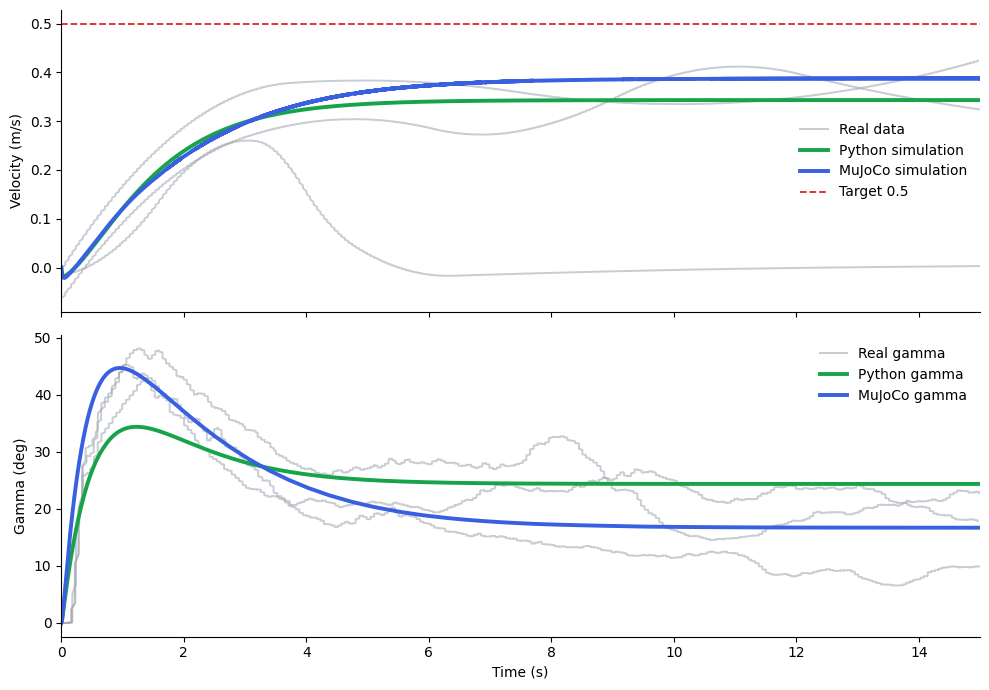

In [5]:
import csv
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

SEGWAY_DIR = Path('/Users/a123/Documents/Unicycle/Matlab_Simu4Unicycle/Derivation/Segway')
SEGWAY_PARAM_TUNERS_DIR = SEGWAY_DIR / 'ParamTuners'
for import_path in (SEGWAY_DIR, SEGWAY_PARAM_TUNERS_DIR):
    if str(import_path) not in sys.path:
        sys.path.insert(0, str(import_path))

from Config import CONTROL_MODE, CONTROL_STRATEGY, MODEL_T
from Parameters import params
from Runner import run_simulation
from getRealData import parse_mixed_csv

MUJOCO_SIM_CSV_DIR = Path('/Users/a123/Desktop/ME_490/Unicycle_Mujoco_Simulation/csv/mydata')
PLOT_OUTPUT_DIR = SEGWAY_DIR / 'Plots' / 'python_mujoco_real_comparison'

REAL_RUN_COLOR = '#9ca3af'
POSITION_PYTHON_COLOR = '#ec4899'
POSITION_MUJOCO_COLOR = '#f59e0b'
VELOCITY_PYTHON_COLOR = '#16a34a'
VELOCITY_MUJOCO_COLOR = '#3860e0'
TARGET_COLOR = '#dc2626'


def activate_inline_matplotlib():
    try:
        from IPython import get_ipython
        ipython = get_ipython()
        if ipython is not None:
            ipython.run_line_magic('matplotlib', 'inline')
        plt.switch_backend('module://matplotlib_inline.backend_inline')
    except Exception as exc:
        print(f'Could not switch matplotlib to inline backend: {exc}')


activate_inline_matplotlib()


def safe_plot_filename(title):
    return ''.join(char if char.isalnum() else '_' for char in title).strip('_').lower()


def save_and_show_figure(fig, title):
    output_dir = PLOT_OUTPUT_DIR
    try:
        output_dir.mkdir(parents=True, exist_ok=True)
    except PermissionError:
        output_dir = Path('/tmp/unicycle_mujoco_plots') / PLOT_OUTPUT_DIR.name
        output_dir.mkdir(parents=True, exist_ok=True)
        print(f'Plot directory was not writable; using fallback: {output_dir}')

    output_path = output_dir / f'{safe_plot_filename(title)}.png'
    fig.savefig(output_path, dpi=160, bbox_inches='tight')
    print(f'Plot saved to: {output_path}')
    plt.show()
    return output_path


def style_axis(axis):
    axis.grid(False)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
    axis.tick_params(direction='out')


def style_legend(axis):
    axis.legend(frameon=False)


def load_simu_csv(csv_path):
    rows = []
    with Path(csv_path).open(newline='') as csv_file:
        reader = csv.DictReader(csv_file)
        for row in reader:
            rows.append({key: float(value) for key, value in row.items()})

    if not rows:
        raise ValueError(f'Empty MuJoCo CSV: {csv_path}')
    return {column: np.array([row[column] for row in rows], dtype=float) for column in rows[0].keys()}


def collect_real_segments(file_paths, mode_name, target_value, value_column, runs_per_file=3, time_limit=15, exclude_run_indices=None):
    exclude_run_indices = set(exclude_run_indices or [])
    real_segments = []

    for file_path in file_paths:
        mode_segments = parse_mixed_csv(str(file_path))
        selected_segments = [
            item['data']
            for item in mode_segments
            if item['mode'] == mode_name and np.isclose(item['target_value'], target_value)
        ]

        for segment_data in selected_segments[:runs_per_file]:
            trimmed_rows = [row for row in segment_data if row[0] <= time_limit]
            if not trimmed_rows:
                continue

            time = np.array([row[0] for row in trimmed_rows], dtype=float)
            value = np.array([row[value_column] for row in trimmed_rows], dtype=float)
            gamma_deg = np.degrees(np.array([row[2] for row in trimmed_rows], dtype=float))
            real_segments.append((time, value, gamma_deg))

    real_segments = [segment for idx, segment in enumerate(real_segments) if idx not in exclude_run_indices]
    if not real_segments:
        raise ValueError(f'No real {mode_name} data found for target {target_value}.')
    return real_segments


def simulate_python_model(mode_name, desired_position, desired_velocity, param_dict, time_span):
    params.I = 0.104
    params.updateParams(param_dict)

    result = []
    run_simulation(
        initial_state=[0.0, 0.0, 0.0, 0.0],
        time_span=time_span,
        control_mode=CONTROL_MODE.POSITION if mode_name == 'position' else CONTROL_MODE.VELOCITY,
        controller_type=CONTROL_STRATEGY.PD,
        desired_gamma=0.0,
        desired_velocity=desired_velocity,
        desired_position=desired_position,
        model_type=MODEL_T.ROLLING_RESISTANCE,
        record_Torque=False,
        export_CSV_flag=False,
        plot_results=False,
        export2list=result,
    )

    value_index = 1 if mode_name == 'position' else 2
    return (
        np.array(result[0], dtype=float),
        np.array(result[value_index], dtype=float),
        np.degrees(np.array(result[3], dtype=float)),
    )


def plot_python_mujoco_real_comparison(config):
    real_segments = collect_real_segments(
        file_paths=config['real_files'],
        mode_name=config['mode_name'],
        target_value=config['target_value'],
        value_column=config['real_value_column'],
        runs_per_file=config['runs_per_file'],
        time_limit=config['time_limit'],
        exclude_run_indices=config['exclude_run_indices'],
    )

    mujoco_data = load_simu_csv(MUJOCO_SIM_CSV_DIR / f"{config['mode_name']}.csv")
    mujoco_time = mujoco_data['time'] - mujoco_data['time'][0]
    mujoco_value = mujoco_data[config['mujoco_value_column']]
    mujoco_gamma_deg = np.degrees(mujoco_data['gamma'])

    python_time, python_value, python_gamma_deg = simulate_python_model(
        mode_name=config['mode_name'],
        desired_position=config['desired_position'],
        desired_velocity=config['desired_velocity'],
        param_dict=config['python_params'],
        time_span=(0, config['time_limit']),
    )

    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    for idx, (real_time, real_value, real_gamma_deg) in enumerate(real_segments):
        axes[0].plot(
            real_time,
            real_value,
            color=REAL_RUN_COLOR,
            alpha=0.55,
            linewidth=1.4,
            label='Real data' if idx == 0 else None,
        )
        axes[1].plot(
            real_time,
            real_gamma_deg,
            color=REAL_RUN_COLOR,
            alpha=0.55,
            linewidth=1.4,
            label='Real gamma' if idx == 0 else None,
        )

    axes[0].plot(
        python_time,
        python_value,
        color=config['python_color'],
        linewidth=2.8,
        label='Python simulation',
    )
    axes[0].plot(
        mujoco_time,
        mujoco_value,
        color=config['mujoco_color'],
        linewidth=2.8,
        label='MuJoCo simulation',
    )
    axes[0].axhline(
        config['target_value'],
        color=TARGET_COLOR,
        linestyle='--',
        linewidth=1.3,
        label=f'Target {config["target_value"]:g}',
    )

    axes[1].plot(
        python_time,
        python_gamma_deg,
        color=config['python_color'],
        linewidth=2.8,
        label='Python gamma',
    )
    axes[1].plot(
        mujoco_time,
        mujoco_gamma_deg,
        color=config['mujoco_color'],
        linewidth=2.8,
        label='MuJoCo gamma',
    )

    axes[0].set_ylabel(config['value_label'])
    axes[1].set_ylabel('Gamma (deg)')
    axes[1].set_xlabel('Time (s)')

    for axis in axes:
        axis.set_xlim(0, config['time_limit'])
        style_axis(axis)
        style_legend(axis)

    plt.tight_layout()
    save_and_show_figure(fig, config['output_name'])


position_python_params = {
    'B': 0.3412352909215786,
    'B_0': 0.011337090552689628,
    'mu_rolling': 0.009937861087525632,
    'm_w': 6.509289047678268,
    'm': 0.7907109523217312,
}

velocity_python_params = {
    'B': 0.29534719835953205,
    'B_0': 0.012007420032393943,
    'mu_rolling': 0.010143346358048193,
    'm_w': 6.555652034148903,
    'm': 0.7443479658510976,
}

comparison_configs = [
    {
        'mode_name': 'position',
        'output_name': 'Position mode Python MuJoCo real comparison',
        'real_files': [
            '/Users/a123/Documents/Unicycle/unicycle_project_umich/LOGS/ValidLogs/P1.0x3.csv',
            '/Users/a123/Documents/Unicycle/unicycle_project_umich/LOGS/ValidLogs/P1.0x3(2).csv',
        ],
        'target_value': 1.0,
        'desired_position': 1.0,
        'desired_velocity': 0.0,
        'real_value_column': 3,
        'mujoco_value_column': 'x_c',
        'value_label': 'Position (m)',
        'python_color': POSITION_PYTHON_COLOR,
        'mujoco_color': POSITION_MUJOCO_COLOR,
        'python_params': position_python_params,
        'runs_per_file': 3,
        'exclude_run_indices': [],
        'time_limit': 15,
    },
    {
        'mode_name': 'velocity',
        'output_name': 'Velocity mode Python MuJoCo real comparison',
        'real_files': [
            '/Users/a123/Documents/Unicycle/unicycle_project_umich/LOGS/ValidLogs/V0.5x3.csv',
            '/Users/a123/Documents/Unicycle/unicycle_project_umich/LOGS/ValidLogs/V0.5x3(2).csv',
        ],
        'target_value': 0.5,
        'desired_position': 0.0,
        'desired_velocity': 0.5,
        'real_value_column': 4,
        'mujoco_value_column': 'x_c_dot',
        'value_label': 'Velocity (m/s)',
        'python_color': VELOCITY_PYTHON_COLOR,
        'mujoco_color': VELOCITY_MUJOCO_COLOR,
        'python_params': velocity_python_params,
        'runs_per_file': 3,
        'exclude_run_indices': [2, 4, 5],
        'time_limit': 15,
    },
]

for comparison_config in comparison_configs:
    plot_python_mujoco_real_comparison(comparison_config)


## Logs vs Python and MuJoCo simulations

Reads the latest CSV log format by command intervals. For velocity mode, only rows between `Mode=velocity, Value=0.5` and the next command marker are treated as velocity trials. Each mode plots position, velocity, gamma, and dgamma against both Python and MuJoCo simulations.



Using 2 position log file(s):
  /Users/a123/Documents/Unicycle/unicycle_project_umich/LOGS/ValidLogs/P1.0x3.csv
  /Users/a123/Documents/Unicycle/unicycle_project_umich/LOGS/ValidLogs/P1.0x3(2).csv
Extracted 6 position command interval(s):
  interval 0: duration=9.50s, x_range=0.776m, v_peak=0.26m/s
  interval 1: duration=10.00s, x_range=0.9m, v_peak=0.302m/s
  interval 2: duration=9.99s, x_range=0.888m, v_peak=0.395m/s
  interval 3: duration=9.97s, x_range=0.736m, v_peak=0.307m/s
  interval 4: duration=9.99s, x_range=0.953m, v_peak=0.328m/s
  interval 5: duration=9.99s, x_range=0.967m, v_peak=0.366m/s
Plot saved to: /Users/a123/Documents/Unicycle/Matlab_Simu4Unicycle/Derivation/Segway/Plots/latest_log_python_mujoco_4subplot_comparison/latest_position_mode_command_intervals_vs_python_and_mujoco_simulation.png


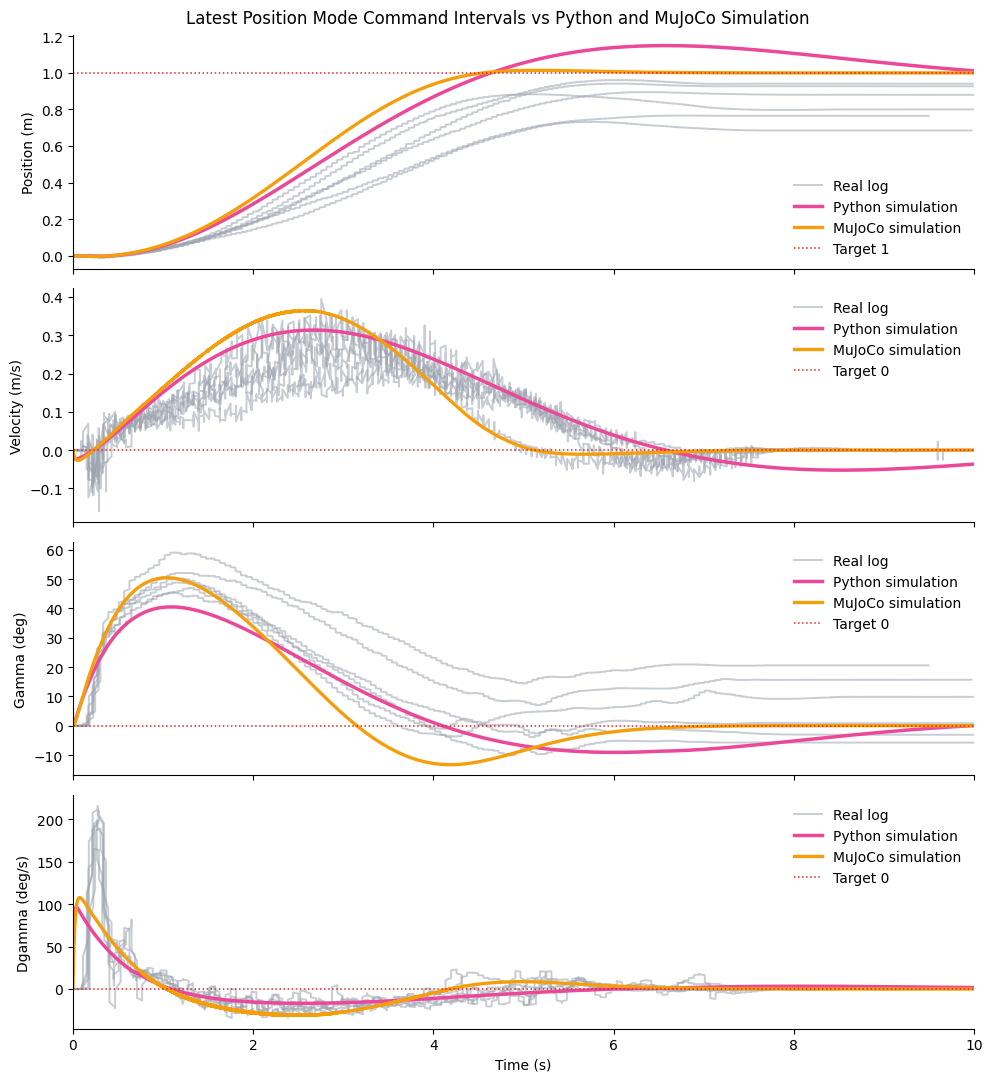

Using 6 velocity log file(s):
  /Users/a123/Documents/Unicycle/unicycle_project_umich/LOGS/ValidLogs/V0.5x3.csv
  /Users/a123/Documents/Unicycle/unicycle_project_umich/LOGS/ValidLogs/V0.5x3(2).csv
  /Users/a123/Documents/Unicycle/unicycle_project_umich/LOGS/ValidLogs/V0.5_1.csv
  /Users/a123/Documents/Unicycle/unicycle_project_umich/LOGS/ValidLogs/V0.5_2.csv
  /Users/a123/Documents/Unicycle/unicycle_project_umich/LOGS/ValidLogs/V0.5_3.csv
  /Users/a123/Documents/Unicycle/unicycle_project_umich/LOGS/ValidLogs/V0.5_4.csv
Extracted 10 velocity command interval(s):
  interval 0: duration=9.99s, x_range=3.16m, v_peak=0.473m/s
  interval 1: duration=10.00s, x_range=0.689m, v_peak=0.44m/s
  interval 2: duration=9.97s, x_range=0.197m, v_peak=0.37m/s
  interval 3: duration=10.00s, x_range=2.56m, v_peak=0.516m/s
  interval 4: duration=9.98s, x_range=0.185m, v_peak=0.527m/s
  interval 5: duration=9.95s, x_range=0.199m, v_peak=0.52m/s
  interval 6: duration=9.99s, x_range=2.42m, v_peak=0.449m/s
  

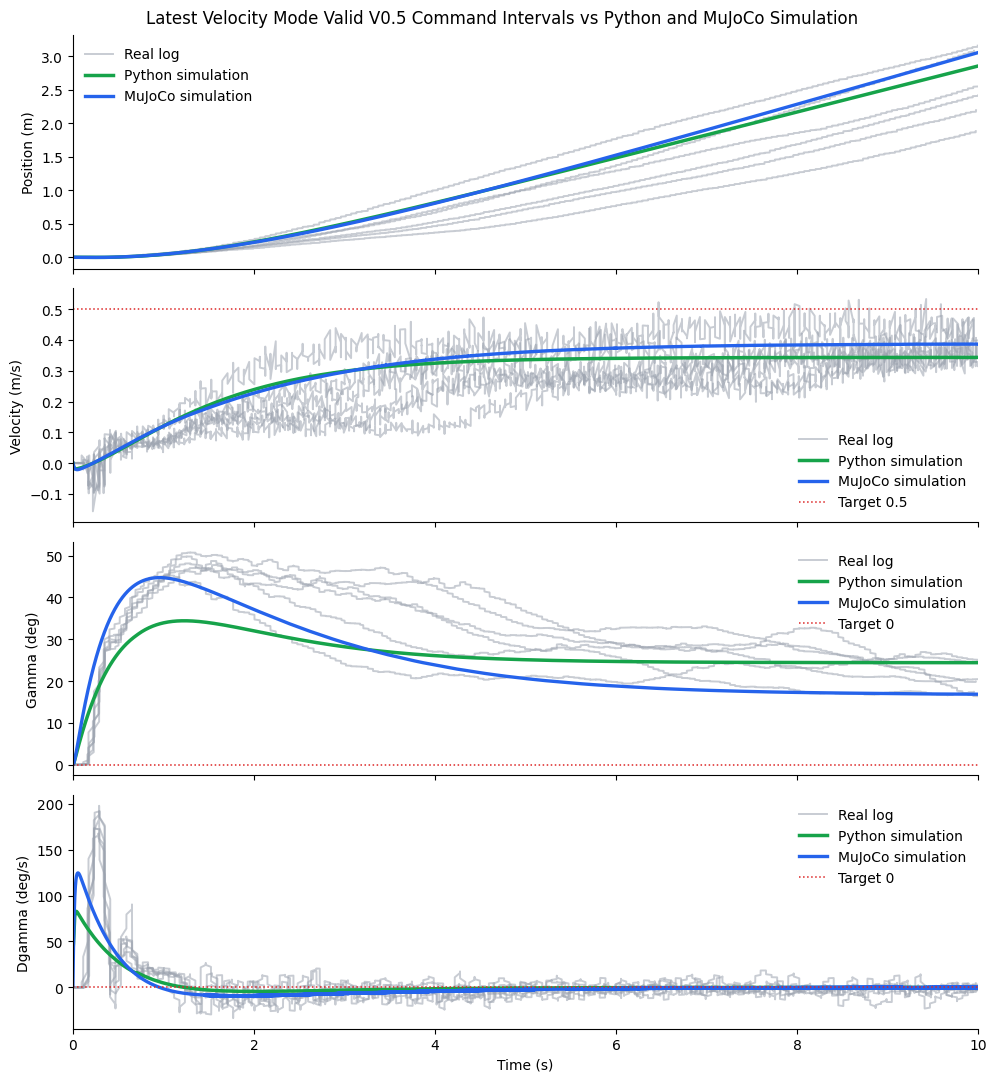

In [4]:
import csv
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

SEGWAY_DIR = Path('/Users/a123/Documents/Unicycle/Matlab_Simu4Unicycle/Derivation/Segway')
for import_path in (SEGWAY_DIR, SEGWAY_DIR / 'ParamTuners'):
    if str(import_path) not in sys.path:
        sys.path.insert(0, str(import_path))

from Config import CONTROL_MODE, CONTROL_STRATEGY, MODEL_T
from Parameters import params
from Runner import run_simulation

UNIOCYCLE_PROJECT_DIR = Path('/Users/a123/Documents/Unicycle/unicycle_project_umich')
LATEST_LOG_DIR = UNIOCYCLE_PROJECT_DIR / 'LOGS' / 'ValidLogs'
LATEST_LOG_FALLBACK_DIRS = [
    UNIOCYCLE_PROJECT_DIR / 'BLE' / 'LOGS' / 'ValidLogs',
    UNIOCYCLE_PROJECT_DIR / '(old)LOGS' / 'ValidLogs',
    UNIOCYCLE_PROJECT_DIR / '(old)LLOOGGSS' / 'ValidLogs',
]
MUJOCO_SIM_CSV_DIR = Path('/Users/a123/Desktop/ME_490/Unicycle_Mujoco_Simulation/csv/mydata')
PLOT_OUTPUT_DIR = SEGWAY_DIR / 'Plots' / 'latest_log_python_mujoco_4subplot_comparison'

PHI_TO_XC_SCALE = 0.2527
REAL_COLOR = '#9ca3af'
DEFAULT_PYTHON_COLOR = '#ec4899'
DEFAULT_MUJOCO_COLOR = '#f59e0b'
TARGET_COLOR = '#dc2626'


def activate_inline_matplotlib():
    try:
        from IPython import get_ipython
        ipython = get_ipython()
        if ipython is not None:
            ipython.run_line_magic('matplotlib', 'inline')
        plt.switch_backend('module://matplotlib_inline.backend_inline')
    except Exception as exc:
        print(f'Could not switch matplotlib to inline backend: {exc}')


activate_inline_matplotlib()


def safe_plot_filename(title):
    return ''.join(char if char.isalnum() else '_' for char in title).strip('_').lower()


def save_and_show_figure(fig, title):
    output_dir = PLOT_OUTPUT_DIR
    try:
        output_dir.mkdir(parents=True, exist_ok=True)
    except PermissionError:
        output_dir = Path('/tmp/unicycle_mujoco_plots') / PLOT_OUTPUT_DIR.name
        output_dir.mkdir(parents=True, exist_ok=True)
        print(f'Plot directory was not writable; using fallback: {output_dir}')

    output_path = output_dir / f'{safe_plot_filename(title)}.png'
    fig.savefig(output_path, dpi=160, bbox_inches='tight')
    print(f'Plot saved to: {output_path}')
    plt.show()
    return output_path


def style_axis(axis):
    axis.grid(False)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
    axis.tick_params(direction='out')
    axis.legend(frameon=False)


def resolve_log_path(file_path):
    file_path = Path(file_path)
    if file_path.exists():
        return file_path

    for fallback_dir in LATEST_LOG_FALLBACK_DIRS:
        fallback_path = fallback_dir / file_path.name
        if fallback_path.exists():
            print(f'Using fallback log path: {fallback_path}')
            return fallback_path

    searched_paths = [file_path] + [fallback_dir / file_path.name for fallback_dir in LATEST_LOG_FALLBACK_DIRS]
    raise FileNotFoundError('CSV file not found. Searched:\n' + '\n'.join(str(path) for path in searched_paths))


def collect_log_paths(patterns, search_dirs=None):
    search_dirs = search_dirs or [LATEST_LOG_DIR, *LATEST_LOG_FALLBACK_DIRS]
    found_paths = []
    seen_names = set()

    for search_dir in search_dirs:
        if not Path(search_dir).exists():
            continue
        for pattern in patterns:
            for path in sorted(Path(search_dir).glob(pattern)):
                # Prefer the first directory that contains a given filename so
                # LOGS/ValidLogs overrides fallback copies with the same name.
                if path.name in seen_names:
                    continue
                found_paths.append(path)
                seen_names.add(path.name)

    if not found_paths:
        raise FileNotFoundError(f'No log files found for patterns: {patterns}')

    return found_paths


def parse_command_interval_log(file_path, mode_name, target_value, time_limit=None, zero_signals=True):
    file_path = resolve_log_path(file_path)
    command_pattern = re.compile(r'Mode=(\w+),\s*Value=([\d\.-]+)')

    with file_path.open(newline='') as csv_file:
        header = next(csv_file).strip().split(',')
        required_columns = {'Timestamp', 'Gamma_rad', 'Phi_rad', 'Dphi_radps'}
        missing_columns = required_columns - set(header)
        if missing_columns:
            raise ValueError(f'{file_path} is missing columns: {sorted(missing_columns)}')

        current_mode = 'balance'
        current_target = 0.0
        current_rows = []
        segments = []

        def flush_segment():
            nonlocal current_rows
            if current_rows:
                segments.append({
                    'file_path': str(file_path),
                    'mode': current_mode,
                    'target_value': current_target,
                    'rows': current_rows,
                })
                current_rows = []

        for raw_line in csv_file:
            line = raw_line.strip()
            if not line:
                continue

            if line.startswith('"--- SEND COMMAND:'):
                flush_segment()
                match = command_pattern.search(line)
                if match:
                    current_mode = match.group(1)
                    current_target = float(match.group(2))
                continue

            if current_mode != mode_name or not np.isclose(current_target, target_value):
                continue

            try:
                values = next(csv.reader([line]))
                row = dict(zip(header, values))
                float(row['Timestamp'])
            except (ValueError, KeyError, StopIteration):
                continue

            current_rows.append(row)

        flush_segment()

    parsed_segments = []
    for segment in segments:
        rows = segment['rows']
        time = np.array([float(row['Timestamp']) for row in rows], dtype=float)
        time = time - time[0]
        position = np.array([float(row['Phi_rad']) for row in rows], dtype=float) * PHI_TO_XC_SCALE
        velocity = np.array([float(row['Dphi_radps']) for row in rows], dtype=float) * PHI_TO_XC_SCALE
        gamma_rad = np.array([float(row['Gamma_rad']) for row in rows], dtype=float)
        gamma_deg = np.degrees(gamma_rad)

        if 'Dgamma_radps' in header:
            dgamma_degps = np.degrees(np.array([float(row['Dgamma_radps']) for row in rows], dtype=float))
        else:
            dgamma_degps = np.degrees(np.gradient(gamma_rad, time, edge_order=1))

        if zero_signals:
            position = position - position[0]
            velocity = velocity - velocity[0]
            gamma_deg = gamma_deg - gamma_deg[0]

        if time_limit is not None:
            keep = time <= time_limit
            time = time[keep]
            position = position[keep]
            velocity = velocity[keep]
            gamma_deg = gamma_deg[keep]
            dgamma_degps = dgamma_degps[keep]

        if len(time) == 0:
            continue

        parsed_segments.append({
            'file_path': segment['file_path'],
            'time': time,
            'position': position,
            'velocity': velocity,
            'gamma_deg': gamma_deg,
            'dgamma_degps': dgamma_degps,
            'duration': float(time[-1]),
        })

    if not parsed_segments:
        raise ValueError(f'No {mode_name} command intervals with target {target_value:g} found in {file_path}')

    return parsed_segments


def filter_real_runs(real_runs, min_position_range=0.0, min_velocity_peak=0.0):
    kept_runs = []
    dropped_runs = []
    for run in real_runs:
        position_range = float(np.nanmax(run['position']) - np.nanmin(run['position'])) if len(run['position']) else 0.0
        velocity_peak = float(np.nanmax(np.abs(run['velocity']))) if len(run['velocity']) else 0.0
        if position_range < min_position_range or velocity_peak < min_velocity_peak:
            dropped_runs.append((run, position_range, velocity_peak))
        else:
            kept_runs.append(run)
    return kept_runs, dropped_runs


def load_mujoco_csv(mode_name, time_limit=None):
    csv_path = MUJOCO_SIM_CSV_DIR / f'{mode_name}.csv'
    if not csv_path.exists():
        raise FileNotFoundError(f'MuJoCo CSV file not found: {csv_path}')

    rows = []
    with csv_path.open(newline='') as csv_file:
        reader = csv.DictReader(csv_file)
        required_columns = {'time', 'gamma', 'x_c', 'x_c_dot'}
        missing_columns = required_columns - set(reader.fieldnames or [])
        if missing_columns:
            raise ValueError(f'{csv_path} is missing columns: {sorted(missing_columns)}')
        for row in reader:
            rows.append(row)

    time = np.array([float(row['time']) for row in rows], dtype=float)
    time = time - time[0]
    gamma_rad = np.array([float(row['gamma']) for row in rows], dtype=float)
    keep = np.ones_like(time, dtype=bool)
    if time_limit is not None:
        keep = time <= time_limit

    return {
        'time': time[keep],
        'position': np.array([float(row['x_c']) for row in rows], dtype=float)[keep],
        'velocity': np.array([float(row['x_c_dot']) for row in rows], dtype=float)[keep],
        'gamma_deg': np.degrees(gamma_rad)[keep],
        'dgamma_degps': np.degrees(np.gradient(gamma_rad, time, edge_order=1))[keep],
    }


def simulate_python_model(config):
    params.I = 0.104
    params.updateParams(config['python_params'])

    result = []
    run_simulation(
        initial_state=[0.0, 0.0, 0.0, 0.0],
        time_span=(0, config['time_limit']),
        control_mode=CONTROL_MODE.POSITION if config['mode_name'] == 'position' else CONTROL_MODE.VELOCITY,
        controller_type=CONTROL_STRATEGY.PD,
        desired_gamma=0.0,
        desired_velocity=config['desired_velocity'],
        desired_position=config['desired_position'],
        model_type=MODEL_T.ROLLING_RESISTANCE,
        record_Torque=False,
        export_CSV_flag=False,
        plot_results=False,
        export2list=result,
    )

    time = np.array(result[0], dtype=float)
    gamma_rad = np.array(result[3], dtype=float)
    return {
        'time': time,
        'position': np.array(result[1], dtype=float),
        'velocity': np.array(result[2], dtype=float),
        'gamma_deg': np.degrees(gamma_rad),
        'dgamma_degps': np.degrees(np.gradient(gamma_rad, time, edge_order=1)),
    }


def plot_command_intervals_vs_simulations(config):
    print(f"Using {len(config['log_paths'])} {config['mode_name']} log file(s):")
    for file_path in config['log_paths']:
        print(f"  {file_path}")

    real_runs = []
    for file_path in config['log_paths']:
        real_runs.extend(parse_command_interval_log(
            file_path=file_path,
            mode_name=config['mode_name'],
            target_value=config['target_value'],
            time_limit=config['time_limit'],
            zero_signals=config.get('zero_signals', True),
        ))

    print(f"Extracted {len(real_runs)} {config['mode_name']} command interval(s):")
    for index, run in enumerate(real_runs):
        position_range = np.nanmax(run['position']) - np.nanmin(run['position'])
        velocity_peak = np.nanmax(np.abs(run['velocity']))
        print(f'  interval {index}: duration={run["duration"]:.2f}s, x_range={position_range:.3g}m, v_peak={velocity_peak:.3g}m/s')

    real_runs, dropped_runs = filter_real_runs(
        real_runs,
        min_position_range=config.get('min_position_range', 0.0),
        min_velocity_peak=config.get('min_velocity_peak', 0.0),
    )
    if dropped_runs:
        print(
            f"Dropped {len(dropped_runs)} {config['mode_name']} trial(s): "
            + ', '.join(f'x_range={position_range:.3g}, v_peak={velocity_peak:.3g}' for _, position_range, velocity_peak in dropped_runs)
        )
    if not real_runs:
        raise ValueError(f"All {config['mode_name']} real trials were filtered out.")

    python_sim = simulate_python_model(config)
    mujoco_sim = load_mujoco_csv(config['mode_name'], time_limit=config['time_limit'])

    fig, axes = plt.subplots(4, 1, figsize=(10, 11), sharex=True)
    subplot_specs = [
        ('position', 'Position (m)', config.get('position_target')),
        ('velocity', 'Velocity (m/s)', config.get('velocity_target')),
        ('gamma_deg', 'Gamma (deg)', 0.0),
        ('dgamma_degps', 'Dgamma (deg/s)', 0.0),
    ]

    for axis, (field, ylabel, target) in zip(axes, subplot_specs):
        for run_index, run in enumerate(real_runs):
            axis.plot(
                run['time'],
                run[field],
                color=REAL_COLOR,
                alpha=0.55,
                linewidth=1.4,
                label='Real log' if run_index == 0 else None,
            )

        axis.plot(
            python_sim['time'],
            python_sim[field],
            color=config.get('python_color', DEFAULT_PYTHON_COLOR),
            linewidth=2.5,
            label='Python simulation',
        )
        axis.plot(
            mujoco_sim['time'],
            mujoco_sim[field],
            color=config.get('mujoco_color', DEFAULT_MUJOCO_COLOR),
            linewidth=2.4,
            label='MuJoCo simulation',
        )

        if target is not None:
            axis.axhline(target, color=TARGET_COLOR, linestyle=':', linewidth=1.1, label=f'Target {target:g}')

        axis.set_ylabel(ylabel)
        axis.set_xlim(0, config['time_limit'])
        style_axis(axis)

    axes[-1].set_xlabel('Time (s)')
    fig.suptitle(config['title'])
    plt.tight_layout()
    save_and_show_figure(fig, config['title'])
    return real_runs, python_sim, mujoco_sim


try:
    position_python_params
except NameError:
    position_python_params = {
        'B': 0.3412352909215786,
        'B_0': 0.011337090552689628,
        'mu_rolling': 0.009937861087525632,
        'm_w': 6.509289047678268,
        'm': 0.7907109523217312,
    }

try:
    velocity_python_params
except NameError:
    velocity_python_params = {
        'B': 0.29534719835953205,
        'B_0': 0.012007420032393943,
        'mu_rolling': 0.010143346358048193,
        'm_w': 6.555652034148903,
        'm': 0.7443479658510976,
    }

latest_command_interval_configs = [
    {
        'mode_name': 'position',
        'title': 'Latest Position Mode Command Intervals vs Python and MuJoCo Simulation',
        'log_paths': [LATEST_LOG_DIR / 'P1.0x3.csv', LATEST_LOG_DIR / 'P1.0x3(2).csv'],
        'target_value': 1.0,
        'desired_position': 1.0,
        'desired_velocity': 0.0,
        'position_target': 1.0,
        'velocity_target': 0.0,
        'python_params': position_python_params,
        'python_color': '#ec4899',
        'mujoco_color': '#f59e0b',
        'time_limit': 10,
        'zero_signals': True,
        'min_position_range': 0.05,
        'min_velocity_peak': 0.02,
    },
    {
        'mode_name': 'velocity',
        'title': 'Latest Velocity Mode Valid V0.5 Command Intervals vs Python and MuJoCo Simulation',
        'log_paths': collect_log_paths(['V0.5x3.csv', 'V0.5x3(2).csv', 'V0.5_*.csv']),
        'target_value': 0.5,
        'desired_position': 0.0,
        'desired_velocity': 0.5,
        'position_target': None,
        'velocity_target': 0.5,
        'python_params': velocity_python_params,
        'python_color': '#16a34a',
        'mujoco_color': '#2563eb',
        'time_limit': 10,
        'zero_signals': True,
        'min_position_range': 1.0,
        'min_velocity_peak': 0.05,
    },
]

latest_command_interval_results = {}
for config in latest_command_interval_configs:
    latest_command_interval_results[config['mode_name']] = plot_command_intervals_vs_simulations(config)





